# IEEE-CIS Fraud Detection — Neural Network (Final Model)

## Architecture Overview

| Component | Detail |
|---|---|
| Input | Individual embedding per categorical column + scaled numerical features |
| Hidden layers | 3 blocks: H → H/2 → H/4, each: `Linear → BatchNorm → GELU → Dropout` |
| Weight init | Xavier uniform (weights), zero (biases) |
| Optimiser | Lookahead(AdamW) |
| Loss | Alpha-balanced Focal Loss (α, γ tuned by Optuna) |
| Regularisation | L2 via AdamW `weight_decay`; Dropout (tuned, range 0.1–0.5) |
| Scheduler | ReduceLROnPlateau (mode=max, tracks val PR-AUC) |
| HP search | Bayesian optimisation via Optuna TPE sampler (30 trials, 8 warm-up epochs each) |
| Gradient clipping | `max_norm=1.0` |
| Primary metric | PR-AUC |
| Threshold | Selected on validation set via F-β (β=2.0) to prioritise recall |
| Checkpointing | `best.pt` (highest val PR-AUC) and `last.pt` (most recent epoch) |

## Notebook Structure

1. Imports & Global Seeding
2. Training Components (`FocalLoss`, `Lookahead`)
3. Dataset & Model (`FraudDataset`, `FraudNet`)
4. Training Pipeline (epoch loop, checkpointing, logging)
5. Hyperparameter Tuning (Optuna Bayesian search)
6. Evaluation & Visualisation (PR-AUC, confusion matrix, PR curve)
7. Main Entrypoint
8. Evaluation
9. Plots
10. Threshold Selection
11. PR Curve
12. Final Results
13. Confusion Matrix
14. Save Model

## 1. Imports and Global Seeding

All random seeds are fixed globally **before** any other operation to ensure full reproducibility
across Python, NumPy, PyTorch (CPU, CUDA, and MPS backends), and the DataLoader shuffle.
The `SEED` constant is used consistently throughout the notebook.

In [1]:
import os
import json
import pickle
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING) #Only show warnings and errors from Optuna - cleaner output

# Set environment variables for MPS backend (Apple Silicon)
os.environ["TORCHDYNAMO_DISABLE"] = "1" # Disable TorchDynamo to avoid potential issues with MPS backend
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # Allow PyTorch to fall back to CPU if MPS is unavailable or encounters issues
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0" # Disable MPS memory caching to prevent OOM errors

# Set random seeds for reproducibility
SEED: int = 42
def set_seed(seed: int = SEED) -> None: 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available(): # Set seeds for all CUDA devices
        torch.cuda.manual_seed(seed) # Set seed for current CUDA device
        torch.cuda.manual_seed_all(seed) # Set seed for all CUDA devices (if multiple GPUs are available)

    if torch.backends.mps.is_available(): # Set seed for MPS (Apple Silicon) if available
        try:
            torch.mps.manual_seed(seed) # Note: MPS seed setting is not officially supported yet, so we catch any potential AttributeError
        except AttributeError:
            pass  

    torch.backends.cudnn.deterministic = True # Ensure deterministic behavior for CUDA operations (may impact performance)
    torch.backends.cudnn.benchmark = False # Disable cuDNN auto-tuning to ensure reproducibility (may impact performance)

set_seed(SEED)

# Detect device with fallback
if torch.backends.mps.is_available():
    try: # Test if MPS actually works
        test_tensor = torch.tensor([1.0], device="mps")
        device = torch.device("mps")
        print("Using device: mps")
    except Exception as e:
        print(f"MPS not available: {e}, falling back to CPU")
        device = torch.device("cpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device : {device}")
print(f"Global seed  : {SEED}")

Using device: mps
Using device : mps
Global seed  : 42


/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Training Components


### 2.1 `FocalLoss`
Alpha-balanced Focal Loss [(Lin et al., 2017)](https://arxiv.org/abs/1708.02002) down-weights
easy negatives so the model focuses on hard, misclassified examples which is critical for the
highly imbalanced fraud detection setting.

$$
\mathcal{L}_{\text{focal}} = -\alpha_t \, (1 - p_t)^{\gamma} \log(p_t)
$$

In [2]:
class FocalLoss(nn.Module): # Custom implementation of focal loss for binary classification

    def __init__(self, alpha: float = 0.75, gamma: float = 2.0) -> None: 
        super().__init__()
        self.alpha = alpha # Which class is more important - the fraudulent transactions
        self.gamma = gamma # Which examples are more important - Focusing on hard examples than easy examples

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor: # logits are the raw outputs from the model (before sigmoid), targets are the true binary labels
        targets = targets.float() # Ensure targets are float for calculations
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none") # Compute bce loss per sample as focal loss applies weight per sample
        probs = torch.sigmoid(logits) # Convert logits to probabilities using sigmoid
        p_t = probs * targets + (1.0 - probs) * (1.0 - targets) # p_t is the probability of the true class where target=1 (fraud) and 1-p_t is the probability of the false class where target=0 (non-fraud)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets) # alpha_t is the weight for the fraud class and 1-alpha_t is the weight for the non-fraud class 
        focal_weight = alpha_t * (1.0 - p_t).pow(self.gamma) # focal_weight = class_weight × difficulty_weight, so hard examples and fraud examples get higher weights
        return (focal_weight * bce).mean() # Return the mean focal loss over the batch


### 2.2 `Lookahead`
Lookahead optimiser wrapper [(Zhang et al., 2019)](https://arxiv.org/abs/1907.08610) maintains
a set of slow weights that are periodically updated toward the fast weights produced by the
inner optimiser (AdamW). This reduces sensitivity to the learning rate and improves convergence
stability.

In [3]:
class Lookahead(torch.optim.Optimizer):
    def __init__(self, base_optimizer: torch.optim.Optimizer, k: int = 5, alpha: float = 0.5) -> None: # k is the number of steps to look ahead, alpha is the learning rate for the slow weights
        self.base_optimizer = base_optimizer 
        self.k = k
        self.alpha = alpha
        self.param_groups = base_optimizer.param_groups # Lookahead gives updates to the base optimizer, so we need to access its param_groups and state
        self.state = base_optimizer.state # Lookahead maintains its own state but also needs to keep track of the base optimizer's state
        self._step_counter = 0 # Counter to keep track of how many steps have been taken with the base optimizer
        self.slow_weights = [[p.clone().detach() for p in group["params"]] for group in self.param_groups] # Initialize slow weights as a copy of the initial parameters

    def step(self, closure=None): 
        loss = self.base_optimizer.step(closure) # Updates fast weights using the base optimizer
        self._step_counter += 1
        if self._step_counter % self.k == 0: # Every k steps, trigger the lookahead update
            for group, slow_group in zip(self.param_groups, self.slow_weights): # Iterate through each parameter group and its corresponding slow weights
                for p, slow_p in zip(group["params"], slow_group): # Loop through each parameter and its corresponding slow weight
                    if p.grad is None: # Skips params w/o gradients
                        continue
                    slow_p.data.add_(self.alpha * (p.data - slow_p.data)) # Update slow weights towards the fast weights by a factor of alpha
                    p.data.copy_(slow_p.data) # Copy the updated slow weights back to the fast weights, so the next k steps will start from this new point
        return loss

    def zero_grad(self, set_to_none: bool = False) -> None: #Lookahead itself doesn't have gradients, but we need to call zero_grad on the base optimizer to clear the gradients of the fast weights
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self) -> dict: # We need to save the state of the base optimizer, the step counter, and the slow weights to be able to resume training later
        return {
            "base_optimizer": self.base_optimizer.state_dict(),
            "step_counter": self._step_counter,
            "slow_weights": [[p.cpu() for p in g] for g in self.slow_weights],
        }

    def load_state_dict(self, state: dict) -> None: # Load the state of the base optimizer, the step counter, and the slow weights when resuming training
        self.base_optimizer.load_state_dict(state["base_optimizer"])
        self._step_counter = state["step_counter"]
        device = next(iter(self.base_optimizer.param_groups[0]["params"])).device
        self.slow_weights = [
            [p.to(device) for p in g] for g in state["slow_weights"]
        ]

## 3. Dataset and Model



### 3.1 `FraudDataset`
A lightweight PyTorch `Dataset` that stores categorical features as `long` tensors
(required by `nn.Embedding`) and numerical features as `float32` tensors.


In [4]:
class FraudDataset(Dataset): # Converts the preprocessed DataFrame into a PyTorch Dataset that can be fed into a DataLoader for training
    def __init__(self, df: pd.DataFrame, cat_cols: list, num_cols: list, target: str) -> None: 
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long) # Categorical features are converted to long tensors for embedding layers
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32) # Numerical features are converted to float tensors for feeding into linear layers
        self.y   = torch.tensor(df[target].values,   dtype=torch.float32) # Target labels are converted to float tensors for binary classification loss functions

    def __len__(self) -> int: # Return the number of samples in the dataset, which is the length of the target tensor
        return len(self.y)

    def __getitem__(self, idx: int): # Return (categorical_features, numerical_features, label) for one sample
        return self.cat[idx], self.num[idx], self.y[idx]


### 3.2 `FraudNet`
Tabular neural network combining:
- **Per-column embeddings** — each categorical column gets its own `nn.Embedding`;
  embedding dimension is `min(50, (vocab_size + 1) // 2)` (a standard heuristic).
- **3-block MLP** — dimensions H → H/2 → H/4, each block: `Linear → BatchNorm → GELU → Dropout`.
- **Xavier uniform** weight initialisation with zero biases for stable training.

In [5]:
class FraudNet(nn.Module): # Main Model Architecture
    def __init__(self, cat_cols: list, vocab_sizes: dict, num_dim: int, hidden_dim: int, dropout: float = 0.3,) -> None: 
        # cat_cols (categorical column names), vocab_sizes (dictionary mapping each cat column to its no. of unique values for embedding sizes), num_dim (no. of numerical features), 
        # hidden_dim (width of the first hidden layer), dropout (dropout rate for regularization)
        super().__init__()

        self.embeddings = nn.ModuleList([nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2)) for col in cat_cols]) # Creates an embedding table for each cat column, where the embedding dimension is determined by the number of unique values in that column (capped at 50)
        emb_dim   = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols) # Total embedding dimension after concatenating all cat embeddings
        input_dim = emb_dim + num_dim # Total input dimension to the MLP after concatenating embeddings and numerical features 

        # Creating a funnel shaped network to encourage learning of compact representations and reduce overfitting, especially important for tabular data with many features
        h1 = hidden_dim 
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)  # floor at 32 to avoid collapse in small configs

        def _block(in_f: int, out_f: int) -> nn.Sequential: # Each hidden block: Linear → BatchNorm → GELU → Dropout
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            _block(input_dim, h1), # 1st hidden layer
            _block(h1, h2), # 2nd hidden layer
            _block(h2, h3), # 3rd hidden layer
            nn.Linear(h3, 1),   # Final Linear layer -> output logit
        )

        self._xavier_init() # Apply Xavier uniform initialization to all Linear layers to help with convergence and stable training

    def _xavier_init(self) -> None: 
        for m in self.modules(): # Iterate through all modules in the network
            if isinstance(m, nn.Linear): # If the module is a Linear layer, apply Xavier uniform initialization to its weights and set biases to zero
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat: torch.Tensor, num: torch.Tensor) -> torch.Tensor: # Forward pass
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)] # Get the embeddings for each categorical column by passing the corresponding column of the input through its embedding layer
        x = torch.cat(embs + [num], dim=1) # Concatenate all embeddings and numerical features to form the input to the MLP
        return self.net(x).squeeze(1) # Pass the concatenated input through the MLP and squeeze the output to get a 1D tensor of logits

    @torch.no_grad() # Decorator to indicate that this method should not track gradients, as it's used for inference
    def predict_proba(self, cat: torch.Tensor, num: torch.Tensor) -> torch.Tensor: # Return sigmoid probabilities (no gradient tracked)
        return torch.sigmoid(self.forward(cat, num))

## 4. Training Pipeline

The training pipeline consists of four functions:

| Function | Purpose |
|---|---|
| `train_epoch` | Single forward/backward pass over the training DataLoader with gradient clipping |
| `save_checkpoint` / `load_checkpoint` | Persist and restore model + optimiser state with full metadata |
| `run_training` | Full training loop: epoch iteration, validation, scheduling, early stopping via checkpointing, Optuna pruning support |

The DataLoader is seeded with the global `SEED` via a `torch.Generator` to ensure
deterministic batch shuffling across runs.

In [6]:
def train_epoch( model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module, device: torch.device,) -> float: # Train the model for 1 epoch and return the average loss over the epoch
    model.train()
    total_loss = 0.0

    for cat, num, y in loader: # Iterate through each batch of categorical features, numerical features, and labels from the DataLoader
        cat, num, y = cat.to(device), num.to(device), y.to(device) # Move the batch to the specified device (GPU/MPS/CPU) for computation
        optimizer.zero_grad() # Clear gradients before the backward pass 
        logits = model(cat, num) # Get the raw output logits from the model for the current batch
        if not torch.isfinite(logits).all(): # Check if any logits are non-finite 
            raise ValueError("Non-finite logits encountered during training.")
        loss = criterion(logits, y) # Compute the loss for the current batch using focal loss
        if not torch.isfinite(loss): # Check if the loss is finite
            raise ValueError("Non-finite loss encountered during training.")
        loss.backward() # Backpropagate the loss to compute gradients for all parameters
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping to prevent exploding gradients, esp for focal loss which can produce large gradients for hard examples
        optimizer.step() # Update the model parameters using the optimizer
        total_loss += loss.item() * len(y)  # Accumulate the total loss, multiplying by batch size to get the sum of losses for all samples in the dataset
    return total_loss / len(loader.dataset) # Return the average loss over the entire dataset for this epoch

def save_checkpoint(path: str, model: nn.Module, optimizer: torch.optim.Optimizer, epoch: int, val_pr: float, config: dict, metadata: dict,) -> None: # Saving the model checkpoint
    torch.save({
        "epoch":            epoch,
        "val_pr_auc":       val_pr,
        "config":           config,
        "model_state_dict": model.state_dict(),
        "optimizer_state":  optimizer.state_dict(),
        "cat_cols":         metadata["cat_cols"],
        "num_cols":         metadata["num_cols"],
        "vocab_sizes":      metadata["vocab_sizes"],
    }, path)
    print(f"    Saved -> {path}")

def load_checkpoint(path: str, model: nn.Module, optimizer: torch.optim.Optimizer = None, device: str = "cuda",) -> dict: # Loading the model checkpoint
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt

def run_training( # Main training loop that orchestrates the entire training process
    config: dict,
    train_ds: Dataset,
    val_ds: Dataset,
    vocab_sizes: dict,
    cat_cols: list,
    num_cols: list,
    metadata: dict,
    device: torch.device,
    run_dir: str = None,
    n_epochs: int = 40,
    trial=None,
) -> tuple:
    
    use_pin_memory = (device.type == "cuda") # Pin memory for faster data transfer to GPU if using CUDA; not needed for MPS or CPU
    g = torch.Generator()
    g.manual_seed(SEED)

    loader_tr = DataLoader( # DataLoader for training dataset with shuffling and seeded generator for reproducibility
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=use_pin_memory,
        generator=g,        
    )
    loader_va = DataLoader( # DataLoader for validation dataset without shuffling
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,         # no shuffle needed for evaluation
        num_workers=0,
        pin_memory=use_pin_memory,
    )

    model = FraudNet( # Build model
        cat_cols=cat_cols,
        vocab_sizes=vocab_sizes,
        num_dim=len(num_cols),
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)

    inner_opt = torch.optim.AdamW( # AdamW optimizer with L2 regularization
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    optimizer = Lookahead(inner_opt, k=config["la_k"], alpha=config["la_alpha"]) # Lookahead wrapper around the base optimizer

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( # LR scheduler monitors val PR-AUC; reduces LR if no improvement for `patience` epochs
        inner_opt,
        mode="max",
        patience=config["sched_patience"],
        factor=config["sched_factor"],
    )

    criterion = FocalLoss(alpha=config["alpha"], gamma=config["gamma"]) # Loss function

    history = {"train_loss": [], "val_pr": []} # Dictionary to store training loss and validation PR-AUC history for each epoch
    best_state = None # Variable to store the state dict of the best model based on validation PR-AUC
    best_val_pr_auc = 0.0 # Variable to keep track of the best validation PR-AUC achieved during training

    print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

    epoch_log_rows = []  # List to store per-epoch log data for later saving to CSV

    for epoch in range(1, n_epochs + 1): # Loop over the specified number of epochs to train the model
        t0 = time.time()
        train_loss = train_epoch(model, loader_tr, optimizer, criterion, device) # Train for one epoch and get the average training loss
        val_pr     = eval_pr_auc(model, loader_va, device)  # Evaluate the model on the validation set and get the PR-AUC score
        scheduler.step(val_pr)   # update LR based on val PR-AUC
        elapsed = time.time() - t0  # Calculate elapsed time for the epoch 
        history["train_loss"].append(train_loss) # Append the average training loss for this epoch to the history dictionary
        history["val_pr"].append(val_pr) # Append the validation PR-AUC for this epoch to the history dictionary

        # Save best checkpoint whenever val PR-AUC improves
        if val_pr > best_val_pr_auc:
            best_val_pr_auc = val_pr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if run_dir:
                save_checkpoint(
                    os.path.join(run_dir, "best.pt"),
                    model, optimizer, epoch, val_pr, config, metadata,
                )

        # Always save the latest checkpoint
        if run_dir:
            save_checkpoint(
                os.path.join(run_dir, "last.pt"),
                model, optimizer, epoch, val_pr, config, metadata,
            )

        print(f"  {epoch:>6}/{n_epochs}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")

        epoch_log_rows.append({
            "epoch":      epoch,
            "train_loss": train_loss,
            "val_pr":     val_pr,
            "time_s":     round(elapsed, 1),
        })

        # Optuna integration: report intermediate value and check for pruning
        if trial is not None: # Only do this if we're running within an Optuna trial, so that we can report the validation PR-AUC for pruning decisions
            trial.report(val_pr, epoch)
            if trial.should_prune(): # Compares this trail's progress to other trials at the same epoch and decides whether to prune this trial early if it's not promising
                raise optuna.exceptions.TrialPruned()

    if run_dir: # Need a run directory to save the training log
        pd.DataFrame(epoch_log_rows).to_csv(
            os.path.join(run_dir, "training_log.csv"),
            index=False,
        )

    return best_val_pr_auc, best_state, history

## 5. Hyperparameter Tuning

Bayesian optimisation via Optuna's TPE (Tree-structured Parzen Estimator) sampler.
The study is seeded (`TPESampler(seed=SEED)`) for reproducibility.

**Search space:**

| Hyperparameter | Type | Range / Options |
|---|---|---|
| `hidden_dim` | categorical | {128, 256, 512} |
| `lr` | log-uniform | [1e-4, 5e-3] |
| `weight_decay` | log-uniform | [1e-6, 1e-2] |
| `batch_size` | categorical | {512, 1024, 4096} |
| `la_k` | categorical | {5, 10} |
| `la_alpha` | uniform | [0.3, 0.8] |
| `sched_patience` | categorical | {3, 5} |
| `sched_factor` | uniform | [0.3, 0.7] |
| `dropout` | uniform | [0.1, 0.5] |
| `alpha` (FocalLoss) | uniform | [0.60, 0.95] |
| `gamma` (FocalLoss) | uniform | [0.5, 5.0] |

Unpromising trials are pruned after 3 warm-up epochs using the **MedianPruner**.

In [ ]:
def bayesian_search(
    train_ds: Dataset,
    val_ds: Dataset,
    vocab_sizes: dict,
    cat_cols: list,
    num_cols: list,
    metadata: dict,
    device: torch.device,
    n_trials: int = 30, # Number of Optuna trials to run where one trail is one sampled hyperparameter config 
    n_epochs_tune: int = 8, # how many epochs to train each trail. Tuning uses shorter runs to save time
) -> tuple:
    
    def objective(trial: optuna.Trial) -> float: 
        config = { # The Seach space for optuna. These hyperparameters and their ranges is chosen based on common best practices for tabular data and some initial experimentation.
            "hidden_dim":     trial.suggest_categorical("hidden_dim",     [128, 256, 512]),
            "batch_size":     trial.suggest_categorical("batch_size",     [512, 1024, 4096]),
            "la_k":           trial.suggest_categorical("la_k",           [5, 10]), # Lookahead steps: how many steps to take with the base optimizer before updating the slow weights. Common values are 5 or 10, which means the lookahead mechanism will update the slow weights every 5 or 10 steps of the base optimizer.
            "la_alpha":       trial.suggest_float("la_alpha",             0.3,  0.8), # Lookahead alpha: the learning rate for the slow weights, which determines how much the slow weights are updated towards the fast weights every k steps. A higher alpha means more aggressive updates to the slow weights
            "sched_patience": trial.suggest_categorical("sched_patience", [3, 5]), # Patience for the learning rate scheduler: how many epochs to wait before reducing the learning rate. Common values are 3 or 5.
            "sched_factor":   trial.suggest_float("sched_factor",         0.3,  0.7), # Factor for reducing the learning rate when the scheduler is triggered. A common value is 0.5, which means the learning rate will be halved when the validation PR-AUC plateaus for `sched_patience` epochs.
            "dropout":        trial.suggest_float("dropout",              0.1,  0.5), # Dropout rate for regularization, which helps prevent overfitting. Common values are between 0.1 and 0.5.  
            "alpha":          trial.suggest_float("alpha",                0.60, 0.95), # Alpha parameter for focal loss, which controls the class imbalance weighting. A higher alpha means more weight is given to the positive class (fraud), which can help improve recall at the cost of precision. Common values are between 0.6 and 0.95.
            "gamma":          trial.suggest_float("gamma",                0.5,  5.0), # Gamma parameter for focal loss, which controls the focusing on hard examples. A higher gamma means more focus on hard examples, which can help improve performance on imbalanced datasets. Common values are between 0.5 and 5.0.
        }

        val_pr, _, _ = run_training( # Run train for one sampled hyperparameter combo. Returns best_val_pr_auc, best_state and history. Only val orauc is kept for pruning decisions for Optuna
            config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols, metadata, device, # Pass all the necessary data and metadata to the training function
            run_dir=None, # no checkpoints during search to save time and disk space, as we only care about the final validation PR-AUC for pruning decisions          
            n_epochs=n_epochs_tune, # No. of epochs to train for each trial.
            trial=trial, 
        )
        return val_pr

    study = optuna.create_study( # Create an Optuna study object to manage the hyperparameter optimization process
        direction="maximize", # We want to maximize the validation PR-AUC, so we set the direction to "maximize"
        sampler=TPESampler(seed=SEED), # seeded for reproducibility
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3), # Uses median pruning to stop unpromising trials early based on the median performance of completed trials at the same epoch, with a warmup period of 3 epochs to allow for some initial training before pruning decisions are made.
    )

    study.optimize( # Run the actual hyperparameter seach for optimisation. 
        objective, # Use the objective fn as a scoring rule for each trial using the returned val PR-AUC for pruning decisions
        n_trials=n_trials, # Number of trials to run, which determines how many different hyperparameter combinations will be evaluated. More trials can lead to better results but will take more time.
        catch=(ValueError,),  # skip trials that produce non-finite outputs
        callbacks=[ # Callback function to print the results of each trial showing the trial number, validation PR-AUC, and the hyperparameters used for that trial. This helps track the progress of the hyperparameter optimization and understand which configurations are performing well.
            lambda s, t: print(
                f"  [Trial {t.number:>2}] val_PR-AUC="
                f"{(t.value if t.value is not None else float('nan')):.4f}"
                f"  params={t.params}"
            )
        ],
    )

    print(f"\nBest trial: val_PR-AUC={study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    return study.best_params, study

## 6. Evaluation and Visualisation

| Function | Purpose |
|---|---|
| `eval_pr_auc` | Compute PR-AUC (average precision) over a DataLoader |
| `evaluate_metrics` | Convenience wrapper for `eval_pr_auc` (infers device from model) |
| `get_predictions` | Collect all ground-truth labels and predicted probabilities |
| `find_best_fbeta_threshold` | Select decision threshold on the validation set by maximising F-β (β=2.0 prioritises recall) |
| `plot_confusion_matrix` | Plot raw-count and row-normalised confusion matrices; save classification report |

In [ ]:
@torch.no_grad() # Dont track gradient for eval 
def eval_pr_auc(model: nn.Module, loader: DataLoader, device: torch.device) -> float: # Quick evaluate the model on the validation set and return the average precision score (PR-AUC)
    model.eval() # Set the model to evaluation mode, which disables dropout and batch normalization updates
    all_p, all_y = [], [] # Lists to store all predicted probabilities and true labels across the entire validation set for calculating PR-AUC
    for cat, num, y in loader: # Iterate through each batch of categorical features, numerical features, and labels from the DataLoader
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy() # Get the predicted probabilities from the model for the current batch, move them to CPU and convert to NumPy array for PR-AUC calculation
        if not np.isfinite(proba).all(): # Check if any predicted probabilities are non-finite (NaN or Inf), which can happen if the model produces extreme logits.
            raise ValueError("Non-finite probabilities encountered during evaluation.")
        all_p.extend(proba) # Append the predicted probabilities for this batch to the all_p list
        all_y.extend(y.numpy()) # Append the true labels for this batch to the all_y list, converting them to NumPy arrays as well
    return average_precision_score(np.array(all_y), np.array(all_p)) # Calculate and return the average precision score (PR-AUC) using the true labels and predicted probabilities for the entire validation set

def evaluate_metrics(model: nn.Module, loader: DataLoader) -> float: # call the eval_pr_auc function to get the PR-AUC score for the given model and DataLoader. 
    return eval_pr_auc(model, loader, next(model.parameters()).device)

@torch.no_grad() # Dont track gradient for eval 
def get_predictions(model: nn.Module, loader: DataLoader, device: torch.device = None,) -> tuple: # get label + probabilities for more analysis like confusion matrix
    model.eval() # Set the model to evaluation mode, which disables dropout and batch normalization updates
    if device is None:
        device = next(model.parameters()).device
    all_p, all_y = [], []
    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()
        if not np.isfinite(proba).all():
            raise ValueError("Non-finite probabilities encountered in get_predictions().")
        all_p.extend(proba)
        all_y.extend(y.numpy())
    return np.array(all_y), np.array(all_p)

def find_best_fbeta_threshold(y_true: np.ndarray, y_proba: np.ndarray, beta: float = 2.0,) -> tuple: # Find the best threshold that max F-beta score, beta is set to 2.0 to weight recall more than precision.
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba) # Get the precision, recall, and thresholds for all possible classification thresholds using the precision_recall_curve function from scikit-learn.
    if len(thresholds) == 0: # If no threshold(same prob predicted for all) return default threshold of 0.5 and corresponding precision, recall, and F-beta score of 0 to avoid errors in downstream analysis
        return 0.5, 0.0, 0.0, 0.0
    beta2 = beta ** 2 # Square the beta value to use in the F-beta score calculation, which allows us to weight recall more than precision when beta > 1
    scores = ( # Calculate the F-beta score for each threshold using the precision and recall values.
        (1 + beta2) * precision[:-1] * recall[:-1] / (beta2 * precision[:-1] + recall[:-1] + 1e-8))  # epsilon avoids division by zero
    best_idx = int(np.argmax(scores)) # Find the index of the threshold that gives the maximum F-beta score. We use np.argmax to get the index of the highest score, and convert it to int for indexing.
    return (float(thresholds[best_idx]), float(scores[best_idx]), float(recall[best_idx]), float(precision[best_idx]),) # Return the best threshold that maximizes the F-beta score, along with the corresponding F-beta score, recall, and precision at that threshold.

def plot_confusion_matrix(y_true: np.ndarray, y_proba: np.ndarray, threshold: float, run_dir: str,) -> None: 
    y_pred = (y_proba >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    labels = ["Non-Fraud", "Fraud"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=[f"Pred {l}" for l in labels], yticklabels=[f"True {l}" for l in labels],)
    axes[0].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Counts")
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) # Right: row-normalised (true positive / false negative rates per class)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=axes[1], xticklabels=[f"Pred {l}" for l in labels], yticklabels=[f"True {l}" for l in labels], )
    axes[1].set_title(f"Confusion Matrix (thresh={threshold:.3f}) — Row-normalised")
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=150)
    plt.close()
    report = classification_report(y_true, y_pred, target_names=labels)
    print(report)
    with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
        f.write(f"Threshold: {threshold:.3f}\n\n{report}")

## 7. Main Entrypoint

The `main()` function orchestrates the full pipeline:

1. Load preprocessed train / val / test splits and column metadata.
2. Run 30-trial Bayesian HP search (8 epochs each).
3. Retrain with the best config for 40 full epochs.
4. Select decision threshold on the validation set via F-β (β=2.0).
5. Evaluate on the test set; plot training curves, PR curve, and confusion matrix.
6. Save all artefacts to `runs/fraud_nn/`.

**Expected output files in `runs/fraud_nn/`:**
- `best.pt` — best model checkpoint (by val PR-AUC)
- `last.pt` — final epoch checkpoint
- `nn_model.pt` — standalone inference checkpoint with full metadata
- `training_log.csv` — per-epoch loss and val PR-AUC
- `hp_search_results.csv` — all Optuna trial results
- `final_metrics.json` — summary of all evaluation metrics
- `nn_training_curves.png` — loss and PR-AUC curves
- `pr_curve.png` — Precision-Recall curve on test set
- `confusion_matrix.png` — confusion matrix (counts + normalised)
- `classification_report.txt` — per-class classification report

In [ ]:
run_dir             = os.path.join("runs", "fraud_nn") # Directory to save model checkpoints, training logs, and evaluation results for this run
n_epochs_full       = 40     # epochs for the final full training run
beta_for_threshold  = 2.0    # F-beta parameter for threshold selection (recall-prioritised)
os.makedirs(run_dir, exist_ok=True) # Create the run directory if it doesn't exist to save checkpoints and logs
print(f"Device  : {device}")
print(f"Seed    : {SEED}")
print(f"Run dir : {run_dir}/")
print("\nLoading preprocessed data...")

train_df = pd.read_csv("../../data/preprocessed/train.csv")
val_df   = pd.read_csv("../../data/preprocessed/val.csv")
test_df  = pd.read_csv("../../data/preprocessed/test.csv")
with open("../../data/preprocessed/column_metadata.pkl", "rb") as f:
    metadata = pickle.load(f)

target     = metadata["target"]
cat_cols   = [c for c in metadata["cat_cols"]  if c in train_df.columns]
num_cols   = [c for c in metadata["num_cols"]  if c in train_df.columns]
vocab_sizes = metadata["vocab_sizes"]
print(f"Categorical : {len(cat_cols)}")
print(f"Numerical   : {len(num_cols)}")

fraud_rate = train_df[target].mean()
print(f"Fraud rate  : {fraud_rate:.4f}  ({train_df[target].sum():.0f} / {len(train_df)})")

train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
val_ds   = FraudDataset(val_df,   cat_cols, num_cols, target)
test_ds  = FraudDataset(test_df,  cat_cols, num_cols, target)
print("\n" + "=" * 60)
print("Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)")
print("=" * 60)

best_params, study = bayesian_search(train_ds, val_ds, vocab_sizes, cat_cols, num_cols, metadata, device, n_trials=30, n_epochs_tune=8,)

study.trials_dataframe().to_csv( os.path.join(run_dir, "hp_search_results.csv"), index=False,) # Save all Optuna trial results for reproducibility

best_config = { # Create a dictionary of the best hyperparameters found by Optuna, ensuring that only the expected keys are included to avoid any issues with unexpected parameters.
    k: best_params[k]
    for k in [ "hidden_dim", "lr", "weight_decay", "batch_size", "la_k", "la_alpha", "sched_patience", "sched_factor", "dropout", "alpha", "gamma",] }

print(f"\n{'=' * 60}")
print(f"Full training for {n_epochs_full} epochs with best config")
print(f"  alpha = {best_config['alpha']:.3f}")
print(f"  gamma = {best_config['gamma']:.3f}")
print(f"{'=' * 60}\n")

use_pin_memory = (device.type == "cuda") # Pin memory for faster data transfer to GPU if using CUDA; not needed for MPS or CPU
lr             = best_config["lr"] 
batch_size     = best_config["batch_size"]

loader_val  = DataLoader( val_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=use_pin_memory,)
loader_test = DataLoader( test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=use_pin_memory, )

best_val_pr_auc, best_state, history = run_training( best_config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols, metadata, device, run_dir=run_dir, n_epochs=n_epochs_full,)

if best_state is None: # Happens if all trials were pruned or had errors
    raise RuntimeError("Training failed: no valid checkpoint was produced.")
    
# Rebuild the model architecture to load the best state dict for evaluation and analysis
model = FraudNet( cat_cols=cat_cols, vocab_sizes=vocab_sizes, num_dim=len(num_cols), hidden_dim=best_config["hidden_dim"], dropout=best_config["dropout"],).to(device) 

Device  : mps
Seed    : 42
Run dir : runs/fraud_nn/

Loading preprocessed data...
Categorical : 41
Numerical   : 427
Fraud rate  : 0.0350  (16531 / 472443)

Bayesian Hyperparameter Search  (Optuna / TPE, 30 trials)
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0426      0.4054     6.4s
       2/8    0.0200      0.5047     5.5s
       3/8    0.0173      0.5482     5.5s
       4/8    0.0159      0.5776     5.6s
       5/8    0.0148      0.6102     5.4s
       6/8    0.0140      0.6263     5.5s
       7/8    0.0132      0.6514     5.7s
       8/8    0.0125      0.6605     5.7s
  [Trial  0] val_PR-AUC=0.6605  params={'hidden_dim': 256, 'lr': 0.0010401663679887319, 'weight_decay': 4.2079886696066345e-06, 'batch_size': 4096, 'la_k': 10, 'la_alpha': 0.3102922471479012, 'sched_patience': 3, 'sched_factor': 0.38493564427131044, 'dropout': 0.17272998688284025, 'alpha': 0.6641915784487018, 'gamma': 1.8690900933179198}
   Epoch      Loss  Val PR-AU

[W 2026-04-14 04:50:42,176] Trial 10 failed with parameters: {'hidden_dim': 128, 'lr': 0.0038425822917037373, 'weight_decay': 0.007553503645583194, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7299795486630184, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.48801618990319595, 'alpha': 0.7843072193880668, 'gamma': 0.6261028799891113} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_16303/3846634018.py", line 28, in objective
    val_pr, _, _ = run_training(
                   ~~~~~~~~~~~~^
        config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
    

  [Trial 10] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.0038425822917037373, 'weight_decay': 0.007553503645583194, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7299795486630184, 'sched_patience': 5, 'sched_factor': 0.6482520093115419, 'dropout': 0.48801618990319595, 'alpha': 0.7843072193880668, 'gamma': 0.6261028799891113}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0468      0.5321    11.7s


[W 2026-04-14 04:50:59,121] Trial 11 failed with parameters: {'hidden_dim': 128, 'lr': 0.003721817372053651, 'weight_decay': 0.009285362053310939, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7275145077153735, 'sched_patience': 5, 'sched_factor': 0.6545211179238095, 'dropout': 0.479545562310499, 'alpha': 0.7640996754641152, 'gamma': 0.5597726501080925} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_16303/3846634018.py", line 28, in objective
    val_pr, _, _ = run_training(
                   ~~~~~~~~~~~~^
        config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
       

  [Trial 11] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003721817372053651, 'weight_decay': 0.009285362053310939, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7275145077153735, 'sched_patience': 5, 'sched_factor': 0.6545211179238095, 'dropout': 0.479545562310499, 'alpha': 0.7640996754641152, 'gamma': 0.5597726501080925}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/8    0.0465      0.5032    11.7s
       2/8    0.0350      0.5705    11.7s


...

  [Trial 26] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.004048632258035059, 'weight_decay': 0.003262766318454477, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7188368741391531, 'sched_patience': 5, 'sched_factor': 0.6968753681613671, 'dropout': 0.4678381778758314, 'alpha': 0.7692531679029063, 'gamma': 0.5150449032006061}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


[W 2026-04-14 04:55:40,244] Trial 27 failed with parameters: {'hidden_dim': 128, 'lr': 0.004172852459281787, 'weight_decay': 0.008695276753956621, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7546908915789985, 'sched_patience': 5, 'sched_factor': 0.6993134344664013, 'dropout': 0.49939867501976826, 'alpha': 0.7669050656205482, 'gamma': 0.5275201683869257} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_16303/3846634018.py", line 28, in objective
    val_pr, _, _ = run_training(
                   ~~~~~~~~~~~~^
        config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
     

  [Trial 27] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.004172852459281787, 'weight_decay': 0.008695276753956621, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7546908915789985, 'sched_patience': 5, 'sched_factor': 0.6993134344664013, 'dropout': 0.49939867501976826, 'alpha': 0.7669050656205482, 'gamma': 0.5275201683869257}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------


[W 2026-04-14 04:55:40,489] Trial 28 failed with parameters: {'hidden_dim': 128, 'lr': 0.003949959163248648, 'weight_decay': 0.005340359171267042, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6945603604246757, 'sched_patience': 5, 'sched_factor': 0.6539466513200292, 'dropout': 0.4997847561815103, 'alpha': 0.7697140652393972, 'gamma': 0.5150870722911867} because of the following error: ValueError('Non-finite logits encountered during training.').
Traceback (most recent call last):
  File "/Users/anbu/Sri/IEEE-CIS-Fraud-Detection-Project/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/w3/r400mrn106n3z9rp99p5c3_80000gp/T/ipykernel_16303/3846634018.py", line 28, in objective
    val_pr, _, _ = run_training(
                   ~~~~~~~~~~~~^
        config, train_ds, val_ds, vocab_sizes, cat_cols, num_cols,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
      

  [Trial 28] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003949959163248648, 'weight_decay': 0.005340359171267042, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6945603604246757, 'sched_patience': 5, 'sched_factor': 0.6539466513200292, 'dropout': 0.4997847561815103, 'alpha': 0.7697140652393972, 'gamma': 0.5150870722911867}
   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
  [Trial 29] val_PR-AUC=nan  params={'hidden_dim': 128, 'lr': 0.003873763227646012, 'weight_decay': 0.006288141198969727, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.7165336280884662, 'sched_patience': 5, 'sched_factor': 0.6883274032305536, 'dropout': 0.4972954745546019, 'alpha': 0.7592044620465881, 'gamma': 0.74868917012201}

Best trial: val_PR-AUC=0.7738
Best params: {'hidden_dim': 256, 'lr': 0.004477427984113198, 'weight_decay': 0.007076022085822006, 'batch_size': 1024, 'la_k': 5, 'la_alpha': 0.6047821669899485, 'sched_patience': 3, 'sched_factor': 0.41145858569464455, 'dropout'

## 8. Evaluation

Loads the best checkpoint (by validation PR-AUC) and evaluates on both the validation and test sets.
PR-AUC (area under the Precision-Recall curve) is the primary metric given the severe class imbalance
in fraud detection.


In [10]:
model.load_state_dict(best_state)
val_pr  = evaluate_metrics(model, loader_val)
test_pr = evaluate_metrics(model, loader_test)

print(f"\n{'=' * 50}")
print(f"  Checkpoint PR-AUC")
print(f"{'=' * 50}")
print(f"  Val  PR-AUC : {val_pr:.4f}")
print(f"  Test PR-AUC : {test_pr:.4f}")


  Checkpoint PR-AUC
  Val  PR-AUC : 0.8423
  Test PR-AUC : 0.8458


## 9. Plots

Visualises two training diagnostics side-by-side:

| Plot | What it shows |
|---|---|
| **Training Loss** | Focal loss per epoch — confirms the model is learning and not diverging |
| **Validation PR-AUC** | Per-epoch PR-AUC with a dashed line marking the best checkpoint |

The combined title annotates the key hyperparameters (learning rate, dropout, batch size, α, γ) so every saved figure is self-documenting.


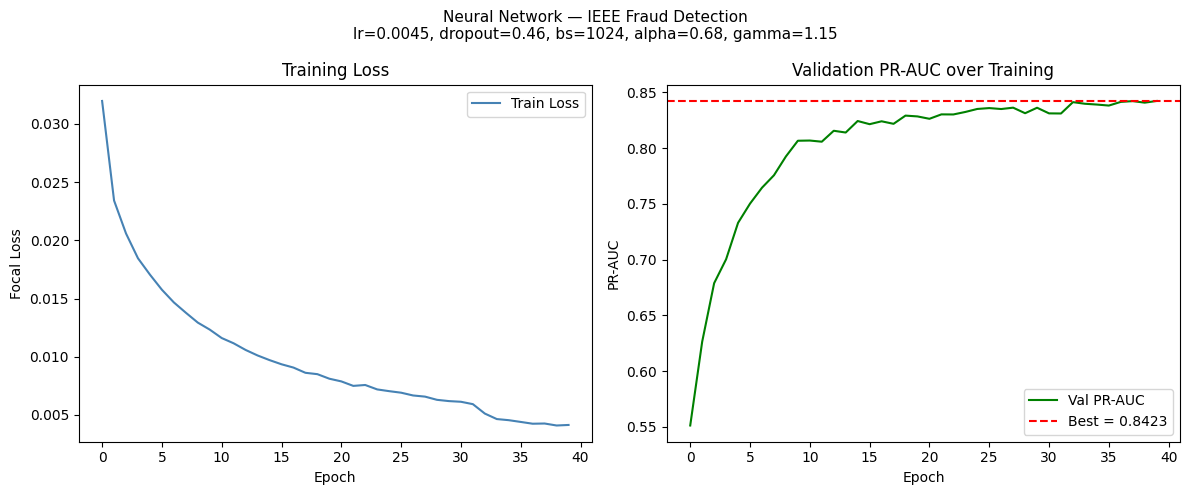

Training curves saved to runs/fraud_nn/nn_training_curves.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(history["train_loss"], label="Train Loss", color="steelblue")
ax.set_xlabel("Epoch"); ax.set_ylabel("Focal Loss")
ax.set_title("Training Loss"); ax.legend()

ax = axes[1]
ax.plot(history["val_pr"], label="Val PR-AUC", color="green")
ax.axhline(y=best_val_pr_auc, color="red", linestyle="--",
            label=f"Best = {best_val_pr_auc:.4f}")
ax.set_xlabel("Epoch"); ax.set_ylabel("PR-AUC")
ax.set_title("Validation PR-AUC over Training"); ax.legend()

cfg_label = (
    f"lr={lr:.4f}, dropout={best_config['dropout']:.2f}, "
    f"bs={batch_size}, alpha={best_config['alpha']:.2f}, "
    f"gamma={best_config['gamma']:.2f}"
)
plt.suptitle(f"Neural Network — IEEE Fraud Detection\n{cfg_label}", fontsize=11)
plt.tight_layout()
curves_path = os.path.join(run_dir, "nn_training_curves.png")
plt.savefig(curves_path, dpi=150)
plt.show()
print(f"Training curves saved to {curves_path}")

## 10. Threshold Selection

Decision threshold is chosen **only on the validation set** to prevent test-set leakage.
`find_best_fbeta_threshold` sweeps candidate thresholds and selects the one that maximises
F-β (β = 2.0), which weights recall twice as heavily as precision — appropriate for fraud
detection where missing a fraud is more costly than a false alarm.


In [ ]:
# Threshold is selected ONLY on the validation set to avoid test-set leakage
val_y_true, val_proba = get_predictions(model, loader_val) # Get the true labels and predicted probabilities for the validation set using the trained model, which will be used to find the best classification threshold based on the F-beta score.
best_thresh, val_best_fbeta, val_best_recall, val_best_precision = find_best_fbeta_threshold(val_y_true, val_proba, beta=beta_for_threshold) # Find Max F-beta threshold on val set
y_true, y_proba = get_predictions(model, loader_test)
y_pred = (y_proba >= best_thresh).astype(int) # Apply the best threshold found from the val set to the predicted probabilities on the test set to get the final binary predictions for confusion matrix and classification report.
test_recall    = recall_score(y_true, y_pred, zero_division=0)
test_precision = precision_score(y_true, y_pred, zero_division=0)
test_f1        = f1_score(y_true, y_pred, zero_division=0)

## 11. PR Curve

Plots the full Precision-Recall curve on the test set with ISO F1 contours for reference.
The selected operating point (validation-tuned threshold) is marked as a red dot, showing
where the model sits on the precision/recall trade-off.


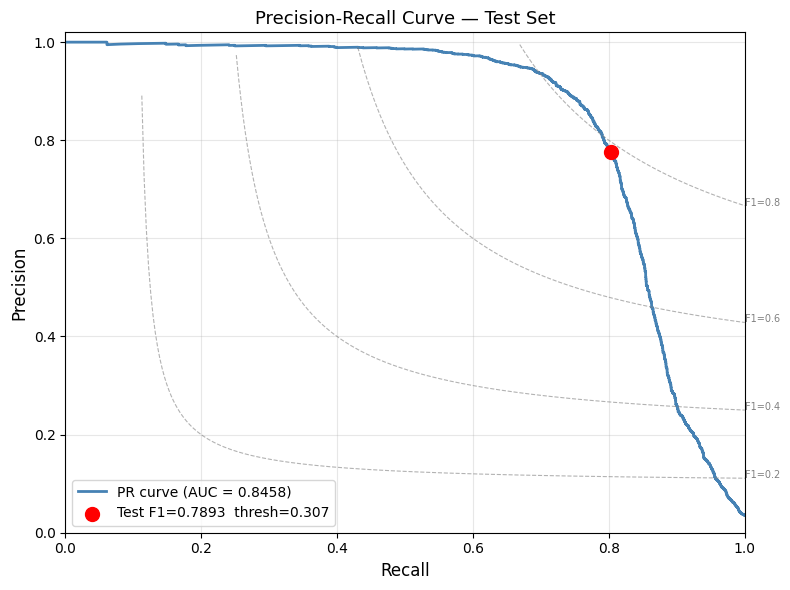

PR curve saved to runs/fraud_nn/pr_curve.png


In [13]:
precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_pts, precision_pts, color="steelblue", lw=2,
        label=f"PR curve (AUC = {test_pr:.4f})")
ax.scatter(test_recall, test_precision, color="red", zorder=5, s=100,
            label=f"Test F1={test_f1:.4f}  thresh={best_thresh:.3f}")

# ISO F1 contours for reference
for f1_iso in [0.2, 0.4, 0.6, 0.8]:
    r_vals = np.linspace(0.01, 1.0, 300)
    p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
    mask   = (p_vals >= 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], "--", color="grey", lw=0.8, alpha=0.6)
    ax.annotate(f"F1={f1_iso}",
                xy=(r_vals[mask][-1], p_vals[mask][-1]),
                fontsize=7, color="grey")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve — Test Set", fontsize=13)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
pr_curve_path = os.path.join(run_dir, "pr_curve.png")
plt.savefig(pr_curve_path, dpi=150)
plt.show()
print(f"PR curve saved to {pr_curve_path}")

## 12. Final Results

Prints a summary of all evaluation metrics at the validation-selected threshold and
serialises them to `runs/fraud_nn/final_metrics.json` for downstream reporting.

| Metric | Split |
|---|---|
| PR-AUC | Val + Test |
| F-β (β=2.0) | Val |
| F1, Recall, Precision | Val + Test |


In [14]:
val_recall = recall_score(
    val_y_true, (val_proba >= best_thresh).astype(int), zero_division=0,
)

print(f"\n{'=' * 50}")
print(f"  Final Results at validation-selected threshold = {best_thresh:.3f}")
print(f"{'=' * 50}")
print(f"  Val  PR-AUC   : {val_pr:.4f}")
print(f"  Test PR-AUC   : {test_pr:.4f}")
print(f"  Val  F{beta_for_threshold:.1f} : {val_best_fbeta:.4f}")
print(f"  Val  Recall   : {val_best_recall:.4f}")
print(f"  Val  Precision: {val_best_precision:.4f}")
print(f"  Test F1       : {test_f1:.4f}")
print(f"  Test Recall   : {test_recall:.4f}")
print(f"  Test Precision: {test_precision:.4f}")

final_metrics = {
    "seed": SEED,
    "best_config": {
        "lr":             lr,
        "batch_size":     batch_size,
        "hidden_dim":     best_config["hidden_dim"],
        "weight_decay":   best_config["weight_decay"],
        "la_k":           best_config["la_k"],
        "la_alpha":       best_config["la_alpha"],
        "sched_patience": best_config["sched_patience"],
        "sched_factor":   best_config["sched_factor"],
        "dropout":        best_config["dropout"],
        "alpha":          best_config["alpha"],
        "gamma":          best_config["gamma"],
    },
    "threshold_selection_beta": beta_for_threshold,
    "val_pr_auc":   val_pr,
    "test_pr_auc":  test_pr,
    "best_thresh":  best_thresh,
    "val_fbeta":    val_best_fbeta,
    "val_recall":   val_recall,
    "val_precision": val_best_precision,
    "test_f1":      test_f1,
    "test_recall":  test_recall,
    "test_precision": test_precision,
}

metrics_path = os.path.join(run_dir, "final_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"\nFinal metrics saved to {metrics_path}")


  Final Results at validation-selected threshold = 0.307
  Val  PR-AUC   : 0.8423
  Test PR-AUC   : 0.8458
  Val  F2.0 : 0.7983
  Val  Recall   : 0.8015
  Val  Precision: 0.7856
  Test F1       : 0.7893
  Test Recall   : 0.8032
  Test Precision: 0.7759

Final metrics saved to runs/fraud_nn/final_metrics.json


## 13. Confusion Matrix

Plots a two-panel confusion matrix on the test set:
- **Raw counts** — absolute TP/FP/FN/TN values.
- **Row-normalised** — recall per class, making class-imbalance effects visible.

Saved to `runs/fraud_nn/` alongside the other artefacts.


In [15]:
plot_confusion_matrix(y_true, y_proba, best_thresh, run_dir)

              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     85482
       Fraud       0.78      0.80      0.79      3099

    accuracy                           0.98     88581
   macro avg       0.88      0.90      0.89     88581
weighted avg       0.99      0.98      0.99     88581



## 14. Save Model

Persists a self-contained inference checkpoint to `runs/fraud_nn/nn_model.pt`.
The file bundles everything needed to reproduce predictions on new data without
re-running training:

| Key | Contents |
|---|---|
| `model_state_dict` | Best model weights |
| `best_config` | Full hyperparameter dict |
| `best_thresh` | Validation-tuned decision threshold |
| `vocab_sizes` / `metadata` | Column metadata for embedding construction |


In [ ]:
# Self-contained: includes weights, config, threshold, and column metadata
model_path = os.path.join(run_dir, "nn_model.pt")
torch.save({
    "model_state_dict": best_state,
    "best_config": {
        "lr":             lr,
        "batch_size":     batch_size,
        "hidden_dim":     best_config["hidden_dim"],
        "weight_decay":   best_config["weight_decay"],
        "la_k":           best_config["la_k"],
        "la_alpha":       best_config["la_alpha"],
        "sched_patience": best_config["sched_patience"],
        "sched_factor":   best_config["sched_factor"],
        "dropout":        best_config["dropout"],
        "alpha":          best_config["alpha"],
        "gamma":          best_config["gamma"],
    },
    "threshold_selection_beta": beta_for_threshold,
    "val_pr_auc":   val_pr,
    "test_pr_auc":  test_pr,
    "best_thresh":  best_thresh,
    "test_f1":      test_f1,
    "test_recall":  test_recall,
    "test_precision": test_precision,
    "cat_cols":     cat_cols,
    "num_cols":     num_cols,
    "vocab_sizes":  vocab_sizes,
    "seed":         SEED,
}, model_path)
print(f"Model saved to {model_path}")

print(f"\n{'=' * 50}")
print(f"  All outputs saved to: {run_dir}/")
print(f"    best.pt") # Best model checkpoint based on validation PR-AUC
print(f"    last.pt") # Last model checkpoint from the final training run
print(f"    nn_model.pt") # Self-contained model file with weights, config, threshold, and metadata for reproducibility and deployment
print(f"    nn_training_curves.png") # Training loss and validation PR-AUC curves over epochs for the final training run
print(f"    pr_curve.png") # Precision-Recall curve for the test set with the selected threshold highlighted
print(f"    confusion_matrix.png") # Confusion matrix for the test set at the selected threshold, showing both counts and row-normalised values
print(f"    classification_report.txt") # Classification report for the test set at the selected threshold, including precision, recall, and F1-score for both classes
print(f"    training_log.csv") # CSV file containing the training loss, validation PR-AUC, and epoch time for each epoch of the final training run, which can be used for further analysis or visualization.
print(f"    hp_search_results.csv") # CSV file containing the results of all Optuna trials during hyperparameter search
print(f"    final_metrics.json") # JSON file containing the final evaluation metrics, best hyperparameters, and other relevant information for reproducibility and record-keeping.
print(f"{'=' * 50}")

Model saved to runs/fraud_nn/nn_model.pt

  All outputs saved to: runs/fraud_nn/
    best.pt
    last.pt
    nn_model.pt
    nn_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    hp_search_results.csv
    final_metrics.json
